# Notebook 06 — Modèle LightGBM (affichage des résultats)

> ⚠️ **Ce notebook ne calcule plus rien.** Depuis la réorganisation du projet, tout le
> calcul est fait par le script `scripts/etape06_modele_lightgbm.py`, à lancer **à la main**, depuis la racine du
> projet :
>
> ```bash
> python scripts/etape06_modele_lightgbm.py
> ```
>
> Ce notebook se contente de **lire et afficher** ce que ce script a produit : les gros
> fichiers de sortie (chemins dans `config.py`) et le rapport d'exécution `06_lightgbm`
> (`outputs/rapports/`, voir `rapports.py`), qui contient tous les compteurs et petits
> tableaux de diagnostic autrefois imprimés au fil des cellules.
>
> Il est donc **léger et ré-exécutable à volonté** (`Run All` en quelques secondes), sans
> jamais relancer un calcul. Si tu changes un paramètre dans `config.py`, relance d'abord
> le script, puis ce notebook.


⚠️ C'est le script **le plus long à tourner** du projet (grille × fenêtres). Deux options
utiles : `--sans-shap` pour sauter le calcul SHAP, et `ANNEES_TEST_PAR_FENETRE` dans
`config.py` pour réduire le nombre de fenêtres.

**Ce que le script a fait :**
1. Construire les mêmes **fenêtres** qu'aux notebooks 04 et 05
2. Pour **chaque fenêtre**, entraîner une petite grille LightGBM avec **arrêt anticipé**
   sur la validation de cette fenêtre
3. Mettre bout à bout les prédictions et calculer le **même R²_oos à la GKX**
4. Agréger l'importance des variables (gain/split) sur toutes les fenêtres + calculer les
   valeurs **SHAP** du modèle final (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal

## 0. Import et chargement des résultats

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('06_lightgbm')
print(rap.resume())

resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_LIGHTGBM)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE)

Rapport '06_lightgbm' produit le 2026-08-06T16:36:41


## 1. Données et fenêtres d'entraînement

In [2]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
print(f"Predicteurs : {rap.valeur('n_predicteurs')}")
rap.table('resume_fenetres')

Panel complet : (2615807, 41)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 41) (198002 a 202112)
Mode : expanding | 3 fenetres generees
Predicteurs : 25


,fenetre,train_debut,train_fin,n_mois_train,validation_debut,validation_fin,test_debut,test_fin,annee_test
0,0,198002,199712,215,199801,200912,201001,201312,2010-2013
1,1,198002,200112,263,200201,201312,201401,201712,2014-2017
2,2,198002,200512,311,200601,201712,201801,202112,2018-2021


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les notebooks 04 et 05, indispensable pour comparer l'ensemble des modèles
équitablement au notebook 07 : `R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`.

## 3. Entraînement avec arrêt anticipé, fenêtre par fenêtre

Plutôt qu'une grande grille comme au notebook 05, on profite d'une fonctionnalité propre à
LightGBM : un budget large d'arbres, mais la performance sur la `validation` de la fenêtre en
cours est **surveillée à chaque arbre ajouté**, et l'entraînement s'arrête dès que ça
n'améliore plus depuis `STOPPING_ROUNDS_LIGHTGBM` arbres d'affilée. Ça évite le
sur-apprentissage et limite le nombre d'hyperparamètres à tester manuellement.

⚠️ Comme pour les autres modèles : c'est bien la `validation` de chaque fenêtre qui sert à
arrêter l'entraînement et à choisir les hyperparamètres, jamais son `test`.

In [3]:
print("Parametres SPECIFIQUES utilises (config.py) :")
for cle, valeur in rap.valeur('params_specifiques').items():
    print(f"  {cle} = {valeur}")
print()
print(f"Grille : {rap.valeur('n_combinaisons_grille')} combinaisons x "
      f"{rap.valeur('n_fenetres')} fenetres")
print(f"Duree totale (recherche d'hyperparametres incluse) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print()
resultats_par_fenetre

Parametres SPECIFIQUES utilises (config.py) :
  grille_num_leaves = [3, 7, 15, 31]
  grille_learning_rate = [0.01]
  grille_min_child_samples = [500, 2000, 5000]
  grille_n_estimators = [500, 1000, 2000]
  stopping_rounds = 60

Grille : 36 combinaisons x 3 fenetres
Duree totale (recherche d'hyperparametres incluse) : 2482.7 s



,fenetre,annee_test,n_train,num_leaves,learning_rate,min_child_samples,n_estimators,nb_arbres_utilises,r2_oos_train,r2_oos_validation,r2_oos_test
0,0,2010-2013,1106697,31,0.01,2000,2000,1317,0.031425,0.004845,0.003710
1,1,2014-2017,1429430,31,0.01,2000,500,116,0.009077,0.003954,0.002826
2,2,2018-2021,1694462,31,0.01,500,500,69,0.006669,0.002936,0.004090


## 3bis. La grille complète : tous les modèles testés au dernier lancement

Comme pour l'Elastic Net, la section précédente ne montre que la combinaison **gagnante** de
chaque fenêtre, alors que le script en a entraîné bien davantage. La surface de performance
complète en dit plus que son seul maximum : un optimum plat indique un choix robuste, un
optimum pointu peut n'être qu'un artefact du bruit de cette période de validation.

ℹ️ Ces tableaux ne concernent que le **dernier lancement** du script. La comparaison entre
plusieurs lancements est le rôle du notebook 08.

In [4]:
grille = rap.table('grille_complete')

print(f"{rap.valeur('n_combinaisons_grille')} combinaisons x {rap.valeur('n_fenetres')} fenetres "
      f"= {rap.valeur('n_modeles_entraines_grille')} modeles entraines au total.")
print()
print("Combinaison retenue par fenetre :")
display(grille[grille['selectionnee']][
    ['fenetre', 'annee_test', 'num_leaves', 'learning_rate', 'min_child_samples',
     'n_estimators', 'nb_arbres_utilises', 'r2_oos_train', 'r2_oos_validation',
     'ecart_train_validation']
].round(4).set_index('fenetre'))

def _etiquettes(valeurs):
    # 1e-05 plutot que 9.999999999999e-06 : les flottants d'une grille se lisent mieux en %g
    return [f"{v:g}" if isinstance(v, float) else str(v) for v in valeurs]


def tracer_heatmap(pivot, titre, etiquette_couleur, cmap, format_valeur="{:.4f}"):
    # Heatmap annotee a partir d'un tableau croise (2 hyperparametres en lignes/colonnes)
    valeurs = pivot.values.astype(float)
    fig, ax = plt.subplots(figsize=(1.7 * len(pivot.columns) + 3.5,
                                    0.75 * len(pivot.index) + 2.5))
    image = ax.imshow(valeurs, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(_etiquettes(pivot.columns))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(_etiquettes(pivot.index))
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)
    ax.set_title(titre)

    milieu = (np.nanmax(valeurs) + np.nanmin(valeurs)) / 2
    for i in range(valeurs.shape[0]):
        for j in range(valeurs.shape[1]):
            v = valeurs[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, format_valeur.format(v), ha='center', va='center',
                    fontsize=9, color='white' if v < milieu else 'black')

    fig.colorbar(image, ax=ax, label=etiquette_couleur)
    plt.tight_layout()
    plt.show()


def tracer_heatmaps_par_fenetre(grille, lignes, colonnes, valeur, titre,
                                etiquette_couleur, cmap, format_valeur="{:.4f}"):
    # Une heatmap par fenetre, cote a cote, sur une MEME echelle de couleurs
    # (indispensable pour comparer les fenetres entre elles d'un coup d'oeil).
    # Le cadre rouge marque la combinaison reellement retenue par cette fenetre.
    numeros = sorted(grille['fenetre'].unique())
    pivots = {n: grille[grille['fenetre'] == n].pivot_table(
                  index=lignes, columns=colonnes, values=valeur, aggfunc='mean')
              for n in numeros}

    toutes_valeurs = np.concatenate([p.values.astype(float).ravel() for p in pivots.values()])
    mini, maxi = np.nanmin(toutes_valeurs), np.nanmax(toutes_valeurs)
    milieu = (mini + maxi) / 2

    premier = pivots[numeros[0]]
    fig, axes = plt.subplots(
        1, len(numeros), squeeze=False,
        figsize=(1.9 * len(premier.columns) * len(numeros) + 2.5,
                 0.75 * len(premier.index) + 3))

    for ax, n in zip(axes[0], numeros):
        pivot = pivots[n]
        valeurs = pivot.values.astype(float)
        image = ax.imshow(valeurs, cmap=cmap, aspect='auto', vmin=mini, vmax=maxi)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(_etiquettes(pivot.columns))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xlabel(pivot.columns.name)
        if n == numeros[0]:
            ax.set_yticklabels(_etiquettes(pivot.index))
            ax.set_ylabel(pivot.index.name)
        else:
            # etiquettes Y sur le premier graphique seulement : sinon elles debordent
            # sur le graphique voisin (l'echelle est commune, donc elles sont identiques)
            ax.set_yticklabels([])

        annee = grille.loc[grille['fenetre'] == n, 'annee_test'].iloc[0]
        ax.set_title(f"Fenetre {n} (test {annee})", fontsize=11)

        for i in range(valeurs.shape[0]):
            for j in range(valeurs.shape[1]):
                v = valeurs[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, format_valeur.format(v), ha='center', va='center',
                        fontsize=8, color='white' if v < milieu else 'black')

        gagnante = grille[(grille['fenetre'] == n) & grille['selectionnee']]
        if len(gagnante):
            ligne_gagnante = gagnante.iloc[0]
            index_liste, colonnes_liste = list(pivot.index), list(pivot.columns)
            if ligne_gagnante[lignes] in index_liste and ligne_gagnante[colonnes] in colonnes_liste:
                i = index_liste.index(ligne_gagnante[lignes])
                j = colonnes_liste.index(ligne_gagnante[colonnes])
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                           edgecolor='red', linewidth=2.5))

    fig.suptitle(titre)
    fig.colorbar(image, ax=axes[0].tolist(), label=etiquette_couleur, fraction=0.025)
    plt.show()

36 combinaisons x 3 fenetres = 108 modeles entraines au total.

Combinaison retenue par fenetre :


,annee_test,num_leaves,learning_rate,min_child_samples,n_estimators,nb_arbres_utilises,r2_oos_train,r2_oos_validation,ecart_train_validation
fenetre,,,,,,,,,
0,2010-2013,31,0.01,2000,2000,1317,0.0314,0.0048,0.0266
1,2014-2017,31,0.01,2000,500,116,0.0091,0.0040,0.0051
2,2018-2021,31,0.01,500,500,69,0.0067,0.0029,0.0037


### Le budget d'arbres est-il seulement atteint ?

`n_estimators` est un **plafond**, pas un nombre imposé : l'arrêt anticipé interrompt
l'entraînement dès que la validation cesse de s'améliorer. Si cet arrêt se déclenche toujours
avant le plus petit budget de la grille, alors **toutes les valeurs de
`GRILLE_N_ESTIMATORS_LIGHTGBM` produisent exactement le même modèle** — la grille est
dupliquée et le temps de calcul gaspillé.

La cellule ci-dessous vérifie ce point. S'il ressort que le budget n'est jamais atteint, la
bonne réaction est soit de revenir à une seule valeur dans `config.py`, soit d'augmenter
`STOPPING_ROUNDS_LIGHTGBM` pour laisser l'entraînement aller plus loin.

In [5]:
pct_atteint = rap.valeur('pct_budget_arbres_atteint')
print(f"Budget d'arbres atteint dans {pct_atteint:.1f}% des modeles entraines.")
if pct_atteint == 0:
    print("-> L'arret anticipe coupe TOUJOURS avant le budget : les differentes valeurs de")
    print("   GRILLE_N_ESTIMATORS_LIGHTGBM donnent des modeles identiques (grille dupliquee).")
elif pct_atteint == 100:
    print("-> Le budget mord TOUJOURS : l'arret anticipe ne sert jamais. Des budgets plus")
    print("   larges ameliorent peut-etre encore le modele -- a tester.")
print()
print("Nb d'arbres reellement utilises, par budget accorde :")
display(grille.groupby('n_estimators')['nb_arbres_utilises']
        .agg(['min', 'mean', 'max']).round(1))

Budget d'arbres atteint dans 8.3% des modeles entraines.

Nb d'arbres reellement utilises, par budget accorde :


,min,mean,max
n_estimators,,,
500,63,235.5,500
1000,63,401.1,1000
2000,63,641.0,1999


### R²_oos de validation, moyenné sur les fenêtres

⚠️ Chaque case est la moyenne sur **toutes les fenêtres** et sur **toutes les valeurs de
`learning_rate` et `min_child_samples`** — ces deux hyperparamètres ne sont pas sur les axes.
La heatmap donne donc la tendance générale des deux paramètres qui t'intéressent ; le tableau
détaillé plus bas montre chaque combinaison individuellement.

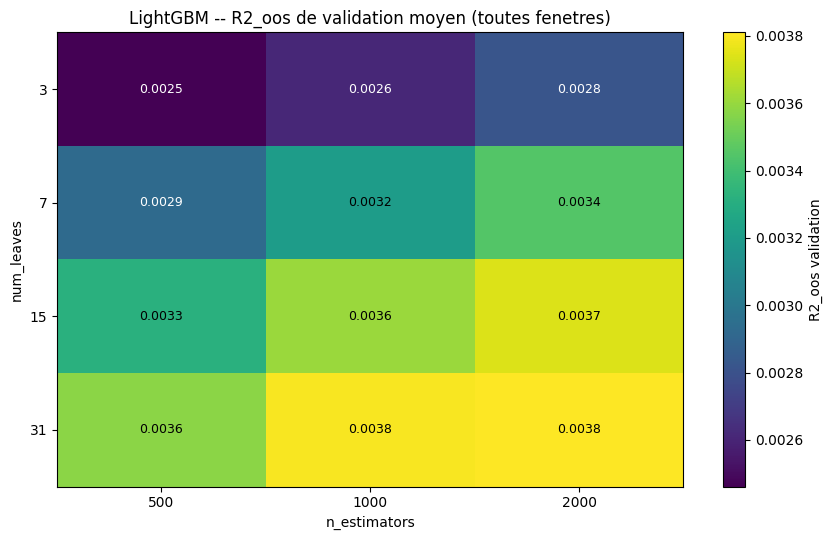

In [6]:
pivot_validation = grille.pivot_table(index='num_leaves', columns='n_estimators',
                                      values='r2_oos_validation', aggfunc='mean')
tracer_heatmap(pivot_validation,
               "LightGBM -- R2_oos de validation moyen (toutes fenetres)",
               "R2_oos validation", cmap='viridis')

#### La même chose, fenêtre par fenêtre

La heatmap précédente moyenne tout : elle dit quelle combinaison marche bien **en général**,
pas si ce « en général » cache des périodes contradictoires. Les heatmaps ci-dessous
décomposent par fenêtre, sur une **échelle de couleurs commune** pour qu'elles restent
comparables entre elles. Le **cadre rouge** marque la combinaison réellement retenue par
chaque fenêtre — le choix de chaque fenêtre est indépendant de celui des autres.

C'est la vue la plus parlante pour juger la stabilité du réglage :

- **Zones foncées au même endroit sur toutes les fenêtres** → l'optimum est stable dans le
  temps, le choix est robuste.
- **Cadre rouge qui saute d'un coin à l'autre** → l'optimum se déplace d'une période à
  l'autre. Ce n'est pas un défaut, mais ça signifie qu'une combinaison unique figée pour tout
  l'historique serait un mauvais choix — et ça justifie précisément le ré-entraînement par
  fenêtre.

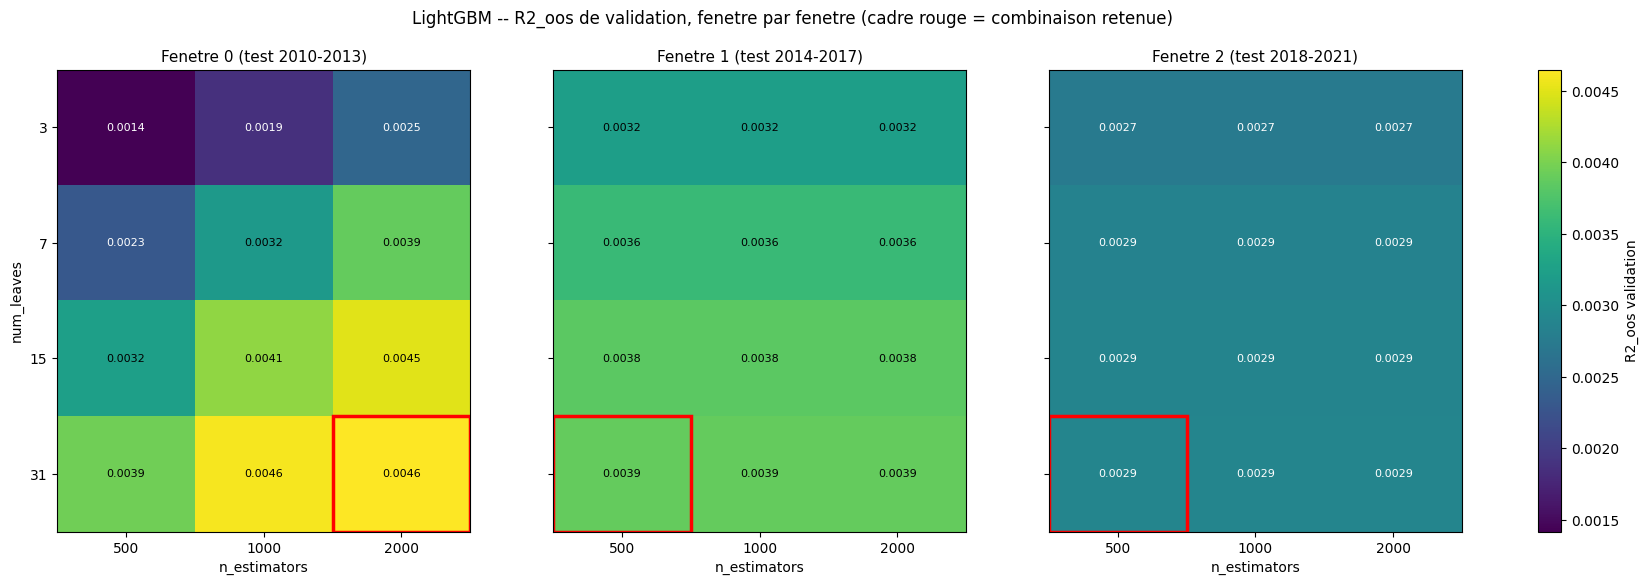

In [7]:
tracer_heatmaps_par_fenetre(grille, lignes='num_leaves', colonnes='n_estimators',
                            valeur='r2_oos_validation',
                            titre="LightGBM -- R2_oos de validation, fenetre par fenetre (cadre rouge = combinaison retenue)",
                            etiquette_couleur="R2_oos validation", cmap='viridis')

In [8]:
cles = ['num_leaves', 'n_estimators', 'learning_rate', 'min_child_samples']
resume_grille = (grille.groupby(cles)
                 .agg(r2_train=('r2_oos_train', 'mean'),
                      r2_validation=('r2_oos_validation', 'mean'),
                      ecart=('ecart_train_validation', 'mean'),
                      arbres_moyens=('nb_arbres_utilises', 'mean'),
                      fois_selectionnee=('selectionnee', 'sum'))
                 .sort_values('r2_validation', ascending=False))

print("Toutes les combinaisons, classees par R2_oos de validation moyen :")
resume_grille.round(4)

Toutes les combinaisons, classees par R2_oos de validation moyen :


r2_train  r2_validation   ecart  arbres_moyens  \
num_leaves n_estimators learning_rate min_child_samples                                                   
31         2000         0.01          2000                 0.0156         0.0039  0.0117       500.6667   
           1000         0.01          2000                 0.0146         0.0039  0.0107       394.6667   
                                      500                  0.0159         0.0038  0.0121       395.3333   
           2000         0.01          500                  0.0159         0.0038  0.0121       395.3333   
15         2000         0.01          2000                 0.0124         0.0038  0.0086       673.3333   
                                      500                  0.0125         0.0038  0.0088       594.3333   
31         2000         0.01          5000                 0.0136         0.0037  0.0099       431.0000   
           1000         0.01          5000                 0.0133         0.0037  0.0096       391.6667   
15         2000         0.01          5000                 0.0117         0.0037  0.0081       661.6667   
           1000         0.01          2000                 0.0107         0.0036  0.0071       396.6667   
31         500          0.01          2000                 0.0122         0.0036  0.0086       228.3333   
15         1000         0.01          500                  0.0110         0.0036  0.0074       395.0000   
31         500          0.01          500                  0.0132         0.0036  0.0096       229.6667   
15         1000         0.01          5000                 0.0103         0.0036  0.0067       397.6667   
31         500          0.01          5000                 0.0113         0.0035  0.0078       229.0000   
7          2000         0.01          2000                 0.0092         0.0035  0.0057       746.3333   
                                      500                  0.0090         0.0035  0.0055       727.3333   
                                      5000                 0.0093         0.0034  0.0059       771.3333   
15         500          0.01          2000                 0.0091         0.0033  0.0058       231.0000   
                                      500                  0.0092         0.0033  0.0059       229.3333   
                                      5000                 0.0088         0.0033  0.0055       232.0000   
7          1000         0.01          2000                 0.0078         0.0032  0.0046       416.0000   
                                      500                  0.0075         0.0032  0.0043       395.6667   
                                      5000                 0.0081         0.0032  0.0049       440.3333   
           500          0.01          5000                 0.0070         0.0029  0.0040       274.3333   
                                      2000                 0.0067         0.0029  0.0038       250.0000   
                                      500                  0.0063         0.0029  0.0034       228.6667   
3          2000         0.01          500                  0.0055         0.0028  0.0027       731.3333   
                                      2000                 0.0055         0.0028  0.0027       731.3333   
                                      5000                 0.0055         0.0028  0.0027       728.3333   
           1000         0.01          500                  0.0048         0.0026  0.0022       398.3333   
                                      2000                 0.0048         0.0026  0.0022       394.0000   
                                      5000                 0.0048         0.0026  0.0022       398.3333   
           500          0.01          500                  0.0043         0.0025  0.0018       231.3333   
                                      2000                 0.0043         0.0025  0.0018       231.3333   
                                      5000                 0.0043         0.0025  0.0018       231

### L'écart train − validation : quelle combinaison sur-apprend le moins ?

Le point est encore plus critique ici que sur l'Elastic Net : un modèle de gradient boosting
peut atteindre un R² d'entraînement très élevé en mémorisant du bruit, ce qui ne se voit pas
du tout dans son R² de validation pris isolément.

- **Écart large et positif** → sur-apprentissage. Sur LightGBM, les coupables habituels sont
  un `num_leaves` trop grand, un `min_child_samples` trop petit, ou un budget d'arbres que
  l'arrêt anticipé ne parvient pas à contenir.
- **Écart proche de zéro** → le modèle généralise. Sur des rendements mensuels, c'est
  généralement du côté des arbres **peu profonds** qu'on le trouve.
- **Écart négatif** → le modèle n'apprend presque rien et prédit quasiment zéro partout.

⚠️ Diagnostic, pas critère de sélection : le script choisit toujours sur le meilleur R²_oos
de validation. Pour sélectionner sur l'écart, il faut modifier la ligne
`meilleur_index = ...` dans `scripts/etape06_modele_lightgbm.py`.

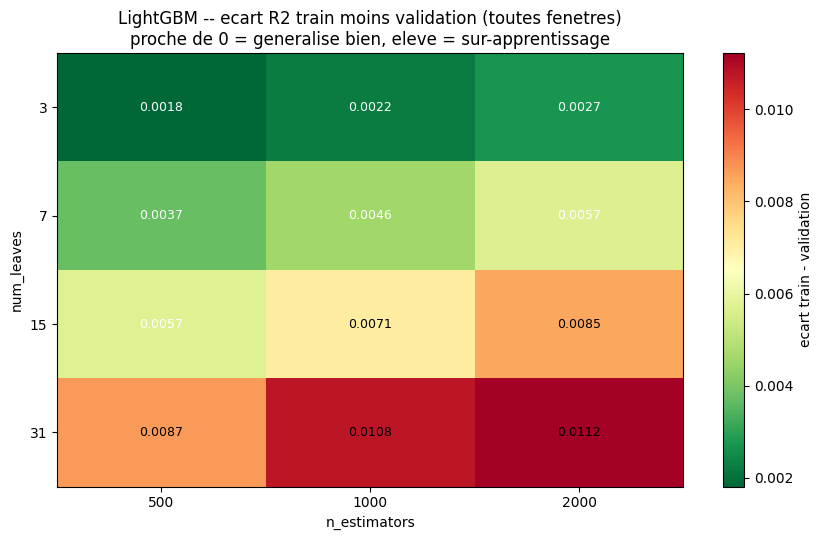

In [9]:
pivot_ecart = grille.pivot_table(index='num_leaves', columns='n_estimators',
                                 values='ecart_train_validation', aggfunc='mean')
tracer_heatmap(pivot_ecart,
               "LightGBM -- ecart R2 train moins validation (toutes fenetres)\n"
               "proche de 0 = generalise bien, eleve = sur-apprentissage",
               "ecart train - validation", cmap='RdYlGn_r')

#### L'écart, fenêtre par fenêtre

Même décomposition pour l'écart train − validation. À surveiller ici : une combinaison dont
l'écart se creuse au fil des fenêtres sur-apprend de plus en plus à mesure que le train
grandit (en mode `expanding`) — un signe qu'il faudrait renforcer la régularisation sur les
fenêtres tardives.

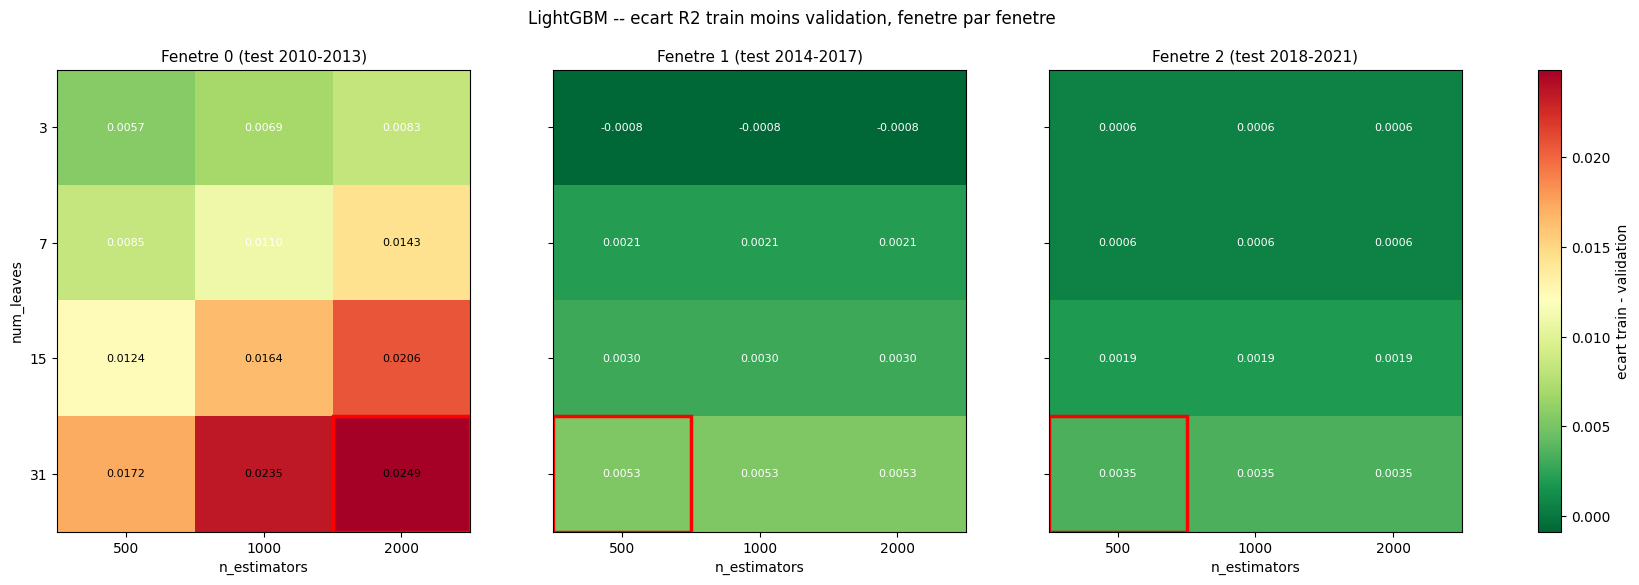

In [10]:
tracer_heatmaps_par_fenetre(grille, lignes='num_leaves', colonnes='n_estimators',
                            valeur='ecart_train_validation',
                            titre="LightGBM -- ecart R2 train moins validation, fenetre par fenetre",
                            etiquette_couleur="ecart train - validation", cmap='RdYlGn_r')

In [11]:
print("Les memes combinaisons, classees cette fois par ecart croissant :")
print("(a lire avec r2_validation : un ecart faible sur un modele qui ne predit rien")
print(" n'a aucun interet -- les deux criteres se lisent ensemble)")
resume_grille.sort_values('ecart').round(4)

Les memes combinaisons, classees cette fois par ecart croissant :
(a lire avec r2_validation : un ecart faible sur un modele qui ne predit rien
 n'a aucun interet -- les deux criteres se lisent ensemble)


r2_train  r2_validation   ecart  arbres_moyens  \
num_leaves n_estimators learning_rate min_child_samples                                                   
3          500          0.01          2000                 0.0043         0.0025  0.0018       231.3333   
                                      500                  0.0043         0.0025  0.0018       231.3333   
                                      5000                 0.0043         0.0025  0.0018       231.3333   
           1000         0.01          2000                 0.0048         0.0026  0.0022       394.0000   
                                      500                  0.0048         0.0026  0.0022       398.3333   
                                      5000                 0.0048         0.0026  0.0022       398.3333   
           2000         0.01          2000                 0.0055         0.0028  0.0027       731.3333   
                                      500                  0.0055         0.0028  0.0027       731.3333   
                                      5000                 0.0055         0.0028  0.0027       728.3333   
7          500          0.01          500                  0.0063         0.0029  0.0034       228.6667   
                                      2000                 0.0067         0.0029  0.0038       250.0000   
                                      5000                 0.0070         0.0029  0.0040       274.3333   
           1000         0.01          500                  0.0075         0.0032  0.0043       395.6667   
                                      2000                 0.0078         0.0032  0.0046       416.0000   
                                      5000                 0.0081         0.0032  0.0049       440.3333   
15         500          0.01          5000                 0.0088         0.0033  0.0055       232.0000   
7          2000         0.01          500                  0.0090         0.0035  0.0055       727.3333   
                                      2000                 0.0092         0.0035  0.0057       746.3333   
15         500          0.01          2000                 0.0091         0.0033  0.0058       231.0000   
                                      500                  0.0092         0.0033  0.0059       229.3333   
7          2000         0.01          5000                 0.0093         0.0034  0.0059       771.3333   
15         1000         0.01          5000                 0.0103         0.0036  0.0067       397.6667   
                                      2000                 0.0107         0.0036  0.0071       396.6667   
                                      500                  0.0110         0.0036  0.0074       395.0000   
31         500          0.01          5000                 0.0113         0.0035  0.0078       229.0000   
15         2000         0.01          5000                 0.0117         0.0037  0.0081       661.6667   
31         500          0.01          2000                 0.0122         0.0036  0.0086       228.3333   
15         2000         0.01          2000                 0.0124         0.0038  0.0086       673.3333   
                                      500                  0.0125         0.0038  0.0088       594.3333   
31         1000         0.01          5000                 0.0133         0.0037  0.0096       391.6667   
           500          0.01          500                  0.0132         0.0036  0.0096       229.6667   
           2000         0.01          5000                 0.0136         0.0037  0.0099       431.0000   
           1000         0.01          2000                 0.0146         0.0039  0.0107       394.6667   
           2000         0.01          2000                 0.0156         0.0039  0.0117       500.6667   
           1000         0.01          500                  0.0159         0.0038  0.0121       395.3333   
           2000         0.01          500                  0.0159         0.0038  0.0121       395

## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

Même logique qu'aux notebooks 04 et 05 : toutes les prédictions bout à bout **d'abord**,
puis un seul R²_oos sur chaque série complète — plutôt qu'une moyenne (biaisée) des R² par
fenêtre.

In [12]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0129
R2_oos validation (pooled, toutes fenetres) : 0.0042
R2_oos test       (pooled, toutes fenetres) : 0.0037



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,LightGBM,expanding,3,0.012932,0.004158,0.003683,e93ca97acbd218fa


## 5. Évolution du R²_oos et du nombre d'arbres au fil des fenêtres

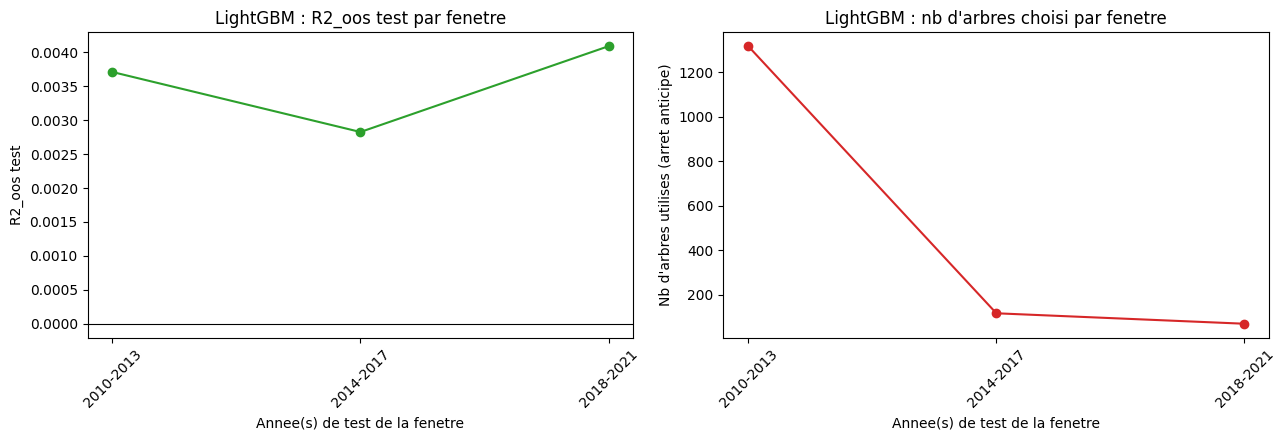

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'],
             marker='o', color='tab:green')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("LightGBM : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['nb_arbres_utilises'],
             marker='o', color='tab:red')
axes[1].set_xlabel("Annee(s) de test de la fenetre")
axes[1].set_ylabel("Nb d'arbres utilises (arret anticipe)")
axes[1].set_title("LightGBM : nb d'arbres choisi par fenetre")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Coup d'œil rapide à l'importance des variables (modèle de la dernière fenêtre)

Contrairement à l'Elastic Net (qui ramène des coefficients à 0), LightGBM donne un score
d'importance basé sur la contribution de chaque variable à la réduction de l'erreur
(`gain`). On regarde ici le modèle de la **dernière fenêtre** — un simple instantané, qui
peut varier d'une fenêtre à l'autre.

In [14]:
importances = rap.table('importance_derniere_fenetre')['importance_gain']
print("Top 15 des variables les plus importantes :")
importances.head(15)

Top 15 des variables les plus importantes :


indmom      2224.409978
mom12m      1076.816898
retvol       642.582989
mom1m        543.438366
maxret       479.996771
sp           443.882359
agr          351.561180
mom6m        282.117880
ep           254.854939
std_turn     253.275599
baspread     217.935919
dolvol       201.271820
mvel1        184.953421
cfp          179.988130
idiovol      137.989549
Name: importance_gain, dtype: float64

## 6bis. Importance agrégée sur toutes les fenêtres (+ SHAP)

L'importance du modèle de la **dernière fenêtre** seule peut être trompeuse : LightGBM peut
redistribuer l'importance différemment d'une fenêtre à l'autre (arbres différents, arrêt
anticipé différent), même si le pouvoir prédictif global reste stable. On regarde donc deux
mesures natives, moyennées **avec leur écart-type** (pour juger la stabilité) sur toutes les
fenêtres :

- **`gain`** : réduction totale de l'erreur apportée par les splits utilisant cette variable
  — la mesure la plus informative économiquement, normalisée à 100 par fenêtre pour rester
  comparable malgré des nombres d'arbres différents.
- **`split`** : nombre de fois que la variable est utilisée pour couper un nœud — mesure la
  fréquence d'usage plutôt que l'impact, utile pour repérer des variables souvent utilisées
  mais pour des gains marginaux.

In [15]:
importance_agregee = pd.read_parquet(config.FICHIER_IMPORTANCE_LIGHTGBM)

print(f"Importance agregee sur {rap.valeur('n_fenetres')} fenetres.")
print(f"{rap.valeur('imp_n_jamais_utilisees')} / {rap.valeur('imp_n_predicteurs')} predicteurs "
      "ne sont utilises dans AUCUN arbre d'aucune fenetre.")
print()
print("Top 20 des predicteurs par gain moyen (avec leur variabilite d'une fenetre a l'autre) :")
importance_agregee.head(20).round(3)

Importance agregee sur 3 fenetres.
0 / 25 predicteurs ne sont utilises dans AUCUN arbre d'aucune fenetre.

Top 20 des predicteurs par gain moyen (avec leur variabilite d'une fenetre a l'autre) :


,gain_moyen_pct,gain_ecart_type_pct,split_moyen,split_ecart_type,jamais_utilisee_pct_fenetres
indmom,27.438,1.973,2733.000,3512.070,0.0
mom12m,9.681,3.710,729.000,886.963,0.0
retvol,8.487,1.204,725.333,972.115,0.0
mom1m,7.559,0.866,1131.000,1567.716,0.0
maxret,5.428,1.136,583.000,790.879,0.0
sp,4.190,1.108,494.333,655.402,0.0
mom6m,4.130,0.605,694.000,990.912,0.0
std_turn,3.456,0.447,598.667,789.571,0.0
dolvol,3.053,0.499,559.333,769.135,0.0
agr,3.018,1.291,366.333,427.130,0.0


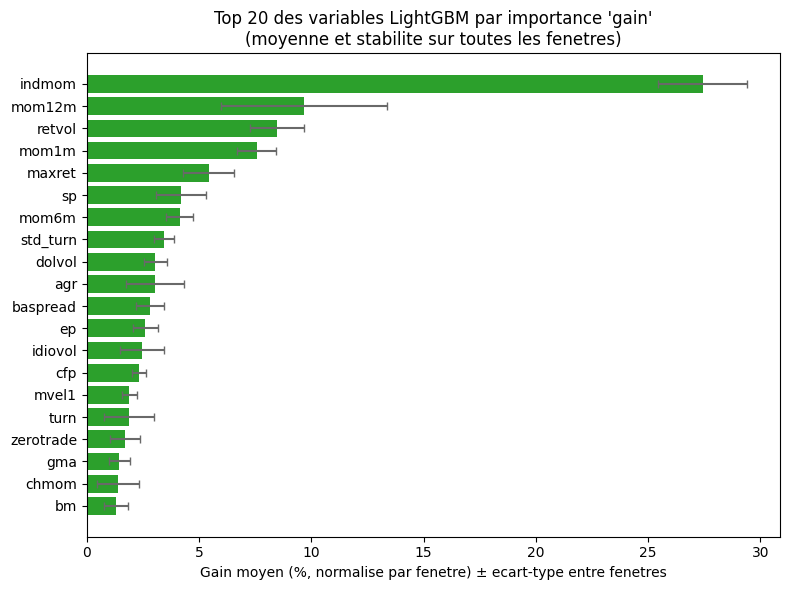

In [16]:
top20_imp = importance_agregee.head(20).sort_values('gain_moyen_pct')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_imp.index, top20_imp['gain_moyen_pct'],
        xerr=top20_imp['gain_ecart_type_pct'], color='tab:green', ecolor='dimgray', capsize=3)
ax.set_xlabel("Gain moyen (%, normalise par fenetre) ± ecart-type entre fenetres")
ax.set_title("Top 20 des variables LightGBM par importance 'gain'\n"
             "(moyenne et stabilite sur toutes les fenetres)")
plt.tight_layout()
plt.show()

### SHAP — contributions signées du modèle de la dernière fenêtre

Contrairement à `gain`/`split` (agrégés, sans direction), SHAP (Lundberg & Lee, 2017) donne
une contribution **signée** par variable et par observation — utile pour voir non seulement
*quelles* variables comptent, mais aussi *dans quel sens*.

⚠️ Les valeurs SHAP sont **calculées par le script** (l'explainer est coûteux) et stockées
dans le rapport : la cellule ci-dessous ne fait que tracer le graphique à partir de ces
valeurs déjà calculées.

c:\Users\aless\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


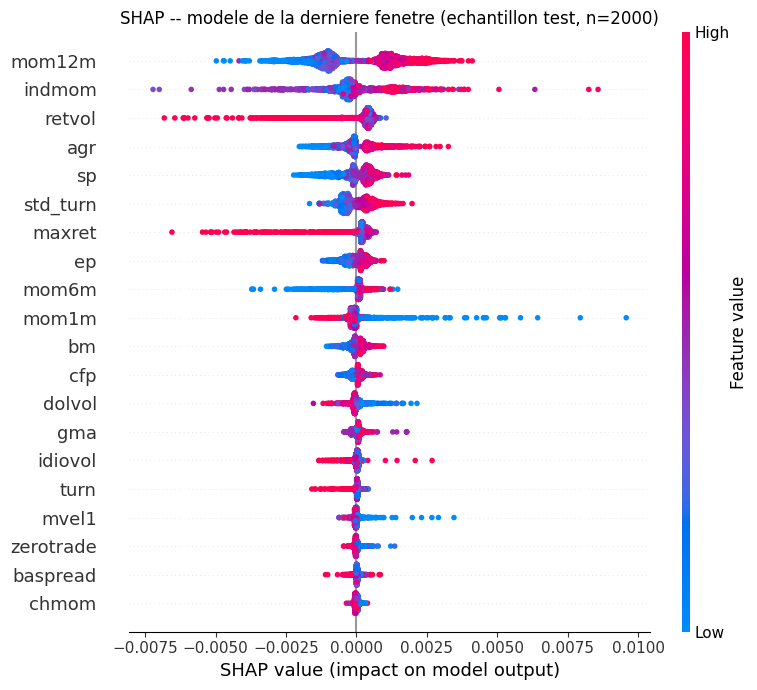

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\outputs\shap_lightgbm_derniere_fenetre.png


In [17]:
if not rap.valeur('shap_calcule'):
    print("Les valeurs SHAP n'ont pas ete calculees (package 'shap' absent, ou script lance")
    print("avec --sans-shap). Pour les obtenir : pip install shap, puis")
    print("    python scripts/etape06_modele_lightgbm.py")
else:
    import shap

    valeurs_shap = rap.table('shap_valeurs')
    X_echantillon = rap.table('shap_echantillon_X')
    n = rap.valeur('shap_taille_echantillon')

    shap.summary_plot(valeurs_shap.values, X_echantillon, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(8, 7)
    plt.title(f"SHAP -- modele de la derniere fenetre (echantillon test, n={n})")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png", dpi=150)
    plt.show()
    print("Graphique sauvegarde :", config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png")

## 7 & 8. Ce que le script a sauvegardé, et le journal des expériences

Les paramètres **spécifiques** sont ici `grille_num_leaves`, `grille_learning_rate`,
`grille_min_child_samples`, `n_estimators` et `stopping_rounds`.

In [18]:
print("Modele final (derniere fenetre) :", config.FICHIER_MODELE_LIGHTGBM)
print("Predictions (toutes fenetres)   :", config.FICHIER_PREDICTIONS_LIGHTGBM)
print("Resultats pooled                :", config.FICHIER_RESULTATS_LIGHTGBM)
print("Resultats par fenetre           :", config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE)
print("Importance agregee              :", config.FICHIER_IMPORTANCE_LIGHTGBM)
print()
print("Cle de cette experience :", rap.valeur('cle_experience'))
if rap.valeur('experience_ajoutee_au_journal'):
    print("-> ligne AJOUTEE au journal des experiences.")
else:
    print("-> experience deja presente dans le journal (memes parametres), rien ajoute : pas de doublon.")
print()
rap.table('apercu_predictions')

Modele final (derniere fenetre) : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\modeles\lightgbm.joblib
Predictions (toutes fenetres)   : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\outputs\predictions_lightgbm.parquet
Resultats pooled                : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\outputs\resultats_lightgbm.parquet
Resultats par fenetre           : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\outputs\resultats_lightgbm_par_fenetre.parquet
Importance agregee              : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy\outputs\importance_lightgbm.parquet

Cle de cette experience : e93ca97acbd218fa
-> ligne AJOUTEE au journal des experiences.



,permno,annee_mois,excess_return,prediction,fenetre
0,10001,201001,-0.018932,0.021606,0
1,10002,201001,0.365854,-0.034682,0
2,10025,201001,-0.088036,0.013021,0
3,10026,201001,0.046296,-0.000271,0
4,10032,201001,0.194171,0.011123,0


## 9. Résumé et prochaines étapes

- Hyperparamètres (`num_leaves`, `learning_rate`, `min_child_samples`) choisis par petite
  grille, avec arrêt anticipé sur la `validation` de **chaque fenêtre** pour fixer
  automatiquement le nombre d'arbres.
- Même métrique et même logique de fenêtres que les notebooks 04 et 05.
- **Importance (section 6bis)** : gain et split moyennés (avec écart-type) sur **toutes** les
  fenêtres, plus une analyse SHAP signée du modèle final.

**Étape suivante :** les 3 modèles sont entraînés — ouvre
`07_evaluation_portefeuilles.ipynb` (portefeuilles long-short par décile), puis
`08_comparaison_experiences.ipynb` (comparaison de tous les lancements passés).